In [1]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import tensorflow as tf

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten

In [2]:
# Load data from csv file
data = pd.read_csv('CII-VNINDEX-History.csv')
data = data.copy()
data.head(10)

,Unnamed: 0,Open,High,Low,Close,Volume,TradingDate
0,0,10850.0,10563.0,10563.0,10563.0,275600,2006-05-18
1,1,10308.0,10032.0,10032.0,10032.0,443520,2006-05-19
2,2,9809.0,9548.0,9548.0,9548.0,64200,2006-05-22
3,3,9331.0,9079.0,9079.0,9079.0,12760,2006-05-23
4,4,8876.0,8641.0,8641.0,8641.0,46460,2006-05-24
5,5,8442.0,8218.0,8218.0,8218.0,156690,2006-05-25
6,6,8029.0,7818.0,7818.0,7818.0,40310,2006-05-26
7,7,7639.0,7434.0,7434.0,7434.0,65110,2006-05-29
8,8,7270.0,7073.0,7073.0,7073.0,19540,2006-05-30
9,9,6922.0,6734.0,6734.0,6734.0,31850,2006-05-31


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4186 entries, 0 to 4185
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   4186 non-null   int64  
 1   Open         4186 non-null   float64
 2   High         4186 non-null   float64
 3   Low          4186 non-null   float64
 4   Close        4186 non-null   float64
 5   Volume       4186 non-null   int64  
 6   TradingDate  4186 non-null   object 
dtypes: float64(4), int64(2), object(1)
memory usage: 229.1+ KB


In [4]:
data.drop(columns=['Unnamed: 0'], inplace=True)

In [5]:
data

,Open,High,Low,Close,Volume,TradingDate
0,10850.0,10563.0,10563.0,10563.0,275600,2006-05-18
1,10308.0,10032.0,10032.0,10032.0,443520,2006-05-19
2,9809.0,9548.0,9548.0,9548.0,64200,2006-05-22
3,9331.0,9079.0,9079.0,9079.0,12760,2006-05-23
4,8876.0,8641.0,8641.0,8641.0,46460,2006-05-24
...,...,...,...,...,...,...
4181,13950.0,14150.0,13500.0,13500.0,3662517,2023-02-22
4182,13500.0,13650.0,13000.0,13500.0,2814643,2023-02-23
4183,13650.0,13650.0,13150.0,13150.0,1366663,2023-02-24
4184,13000.0,13450.0,12850.0,12950.0,1975666,2023-02-27


In [6]:
# Select multiple features
features = ['Open', 'High', 'Low', 'Close', 'Volume'] # Exclude Trading Date
target = 'Close'

df = data[features]

In [7]:
# Create time windows
k = 3 # 3 days forecast

X_data = []
y_data = []
window_size = 30
num_features = len(features)

for i in range(0, len(df) - window_size - k):
    data_feature = []

    for j in range(window_size):
        data_feature.append(df.iloc[i + j].values)

    label = df.iloc[i + window_size + k - 1][target]

    X_data.append(data_feature)
    y_data.append([label])

X_data = np.array(X_data)
y_data = np.array(y_data)

print("X_data shape:", X_data.shape)
print("y_data shape:", y_data.shape)

X_data shape: (4153, 30, 5)
y_data shape: (4153, 1)


In [8]:
# Train / Val / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, shuffle=False)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, shuffle=False)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (2657, 30, 5)
Val: (665, 30, 5)
Test: (831, 30, 5)


In [9]:
# Normalize
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# reshape for scaler
X_train_reshaped = X_train.reshape(-1, num_features)
X_val_reshaped = X_val.reshape(-1, num_features)
X_test_reshaped = X_test.reshape(-1, num_features)

# fit on train only
X_train_norm = scaler_X.fit_transform(X_train_reshaped).reshape(X_train.shape)
X_val_norm = scaler_X.transform(X_val_reshaped).reshape(X_val.shape)
X_test_norm = scaler_X.transform(X_test_reshaped).reshape(X_test.shape)

# scale y
y_train_norm = scaler_y.fit_transform(y_train)
y_val_norm = scaler_y.transform(y_val)
y_test_norm = scaler_y.transform(y_test)

In [10]:
# Cross-validation
tscv = TimeSeriesSplit(n_splits=5)

cv_losses = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_norm)):

    # time series split train/val
    X_tr, X_val_cv = X_train_norm[train_idx], X_train_norm[val_idx]
    y_tr, y_val_cv = y_train_norm[train_idx], y_train_norm[val_idx]

    # rebuild model for every fold
    model_cv = Sequential()

    model_cv.add(Conv1D(64, 3, activation='relu',
                        input_shape=(window_size, num_features),
                        padding='same'))
    model_cv.add(MaxPooling1D(2))

    model_cv.add(Conv1D(128, 3, activation='relu', padding='same'))
    model_cv.add(MaxPooling1D(2))

    model_cv.add(Conv1D(64, 3, activation='relu', padding='same'))
    model_cv.add(MaxPooling1D(2))

    model_cv.add(Flatten())
    model_cv.add(Dense(100, activation='relu'))
    model_cv.add(Dense(1))

    model_cv.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='mse'
    )

    # train
    model_cv.fit(
        X_tr, y_tr,
        validation_data=(X_val_cv, y_val_cv),
        epochs=5,
        batch_size=128,
        verbose=0
    )

    # evaluate fold
    loss = model_cv.evaluate(X_val_cv, y_val_cv, verbose=0)
    cv_losses.append(loss)

    print(f"Fold {fold+1} loss: {loss}")

print("Mean loss:", np.mean(cv_losses))
print("Std loss:", np.std(cv_losses))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 loss: 0.0033206099178642035
Fold 2 loss: 0.0010304009774699807
Fold 3 loss: 0.0011967252939939499
Fold 4 loss: 0.0018349646124988794
Fold 5 loss: 0.0012421435676515102
Mean loss: 0.0017249688738957048
Std loss: 0.0008429419342410502


In [11]:
# Build model
model = Sequential()

model.add(Conv1D(64, 3, activation='relu',
                   input_shape=(window_size, num_features), padding='same'))
model.add(MaxPooling1D(2))

model.add(Conv1D(128, 3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))

model.add(Conv1D(64, 3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))

model.add(Flatten())
model.add(Dense(100, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mse',
    metrics=['mse']
)

In [12]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 30, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 7, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        19,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,769 (272.54 KB)

 Trainable params: 69,769 (272.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train model
history = model.fit(
    X_train_norm, y_train_norm,
    validation_data=(X_val_norm, y_val_norm),
    epochs=10,
    batch_size=128
)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0118 - mse: 0.0118 - val_loss: 0.0097 - val_mse: 0.0097
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0024 - mse: 0.0024 - val_loss: 0.0023 - val_mse: 0.0023
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0016 - mse: 0.0016 - val_loss: 0.0018 - val_mse: 0.0018
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 0.0017 - val_mse: 0.0017
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0010 - mse: 0.0010 - val_loss: 0.0014 - val_mse: 0.0014
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 8.8651e-04 - mse: 8.8651e-04 - val_loss: 0.0013 - val_mse: 0.0013
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 8.6442e-04 - mse: 8.6442e-04 - val_loss: 0.0014 - val_mse: 0.0014
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 6.8610e-04 - mse: 6.8610e-04 - val_loss: 0.0017 - val_mse: 0.0017
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s

In [14]:
# Evaluate
y_pred_norm = model.predict(X_test_norm)

print("MSE (normalized):", mean_squared_error(y_test_norm, y_pred_norm))

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
MSE (normalized): 0.007642617089680483


In [15]:
# Denormalize predictions
y_pred = scaler_y.inverse_transform(y_pred_norm)

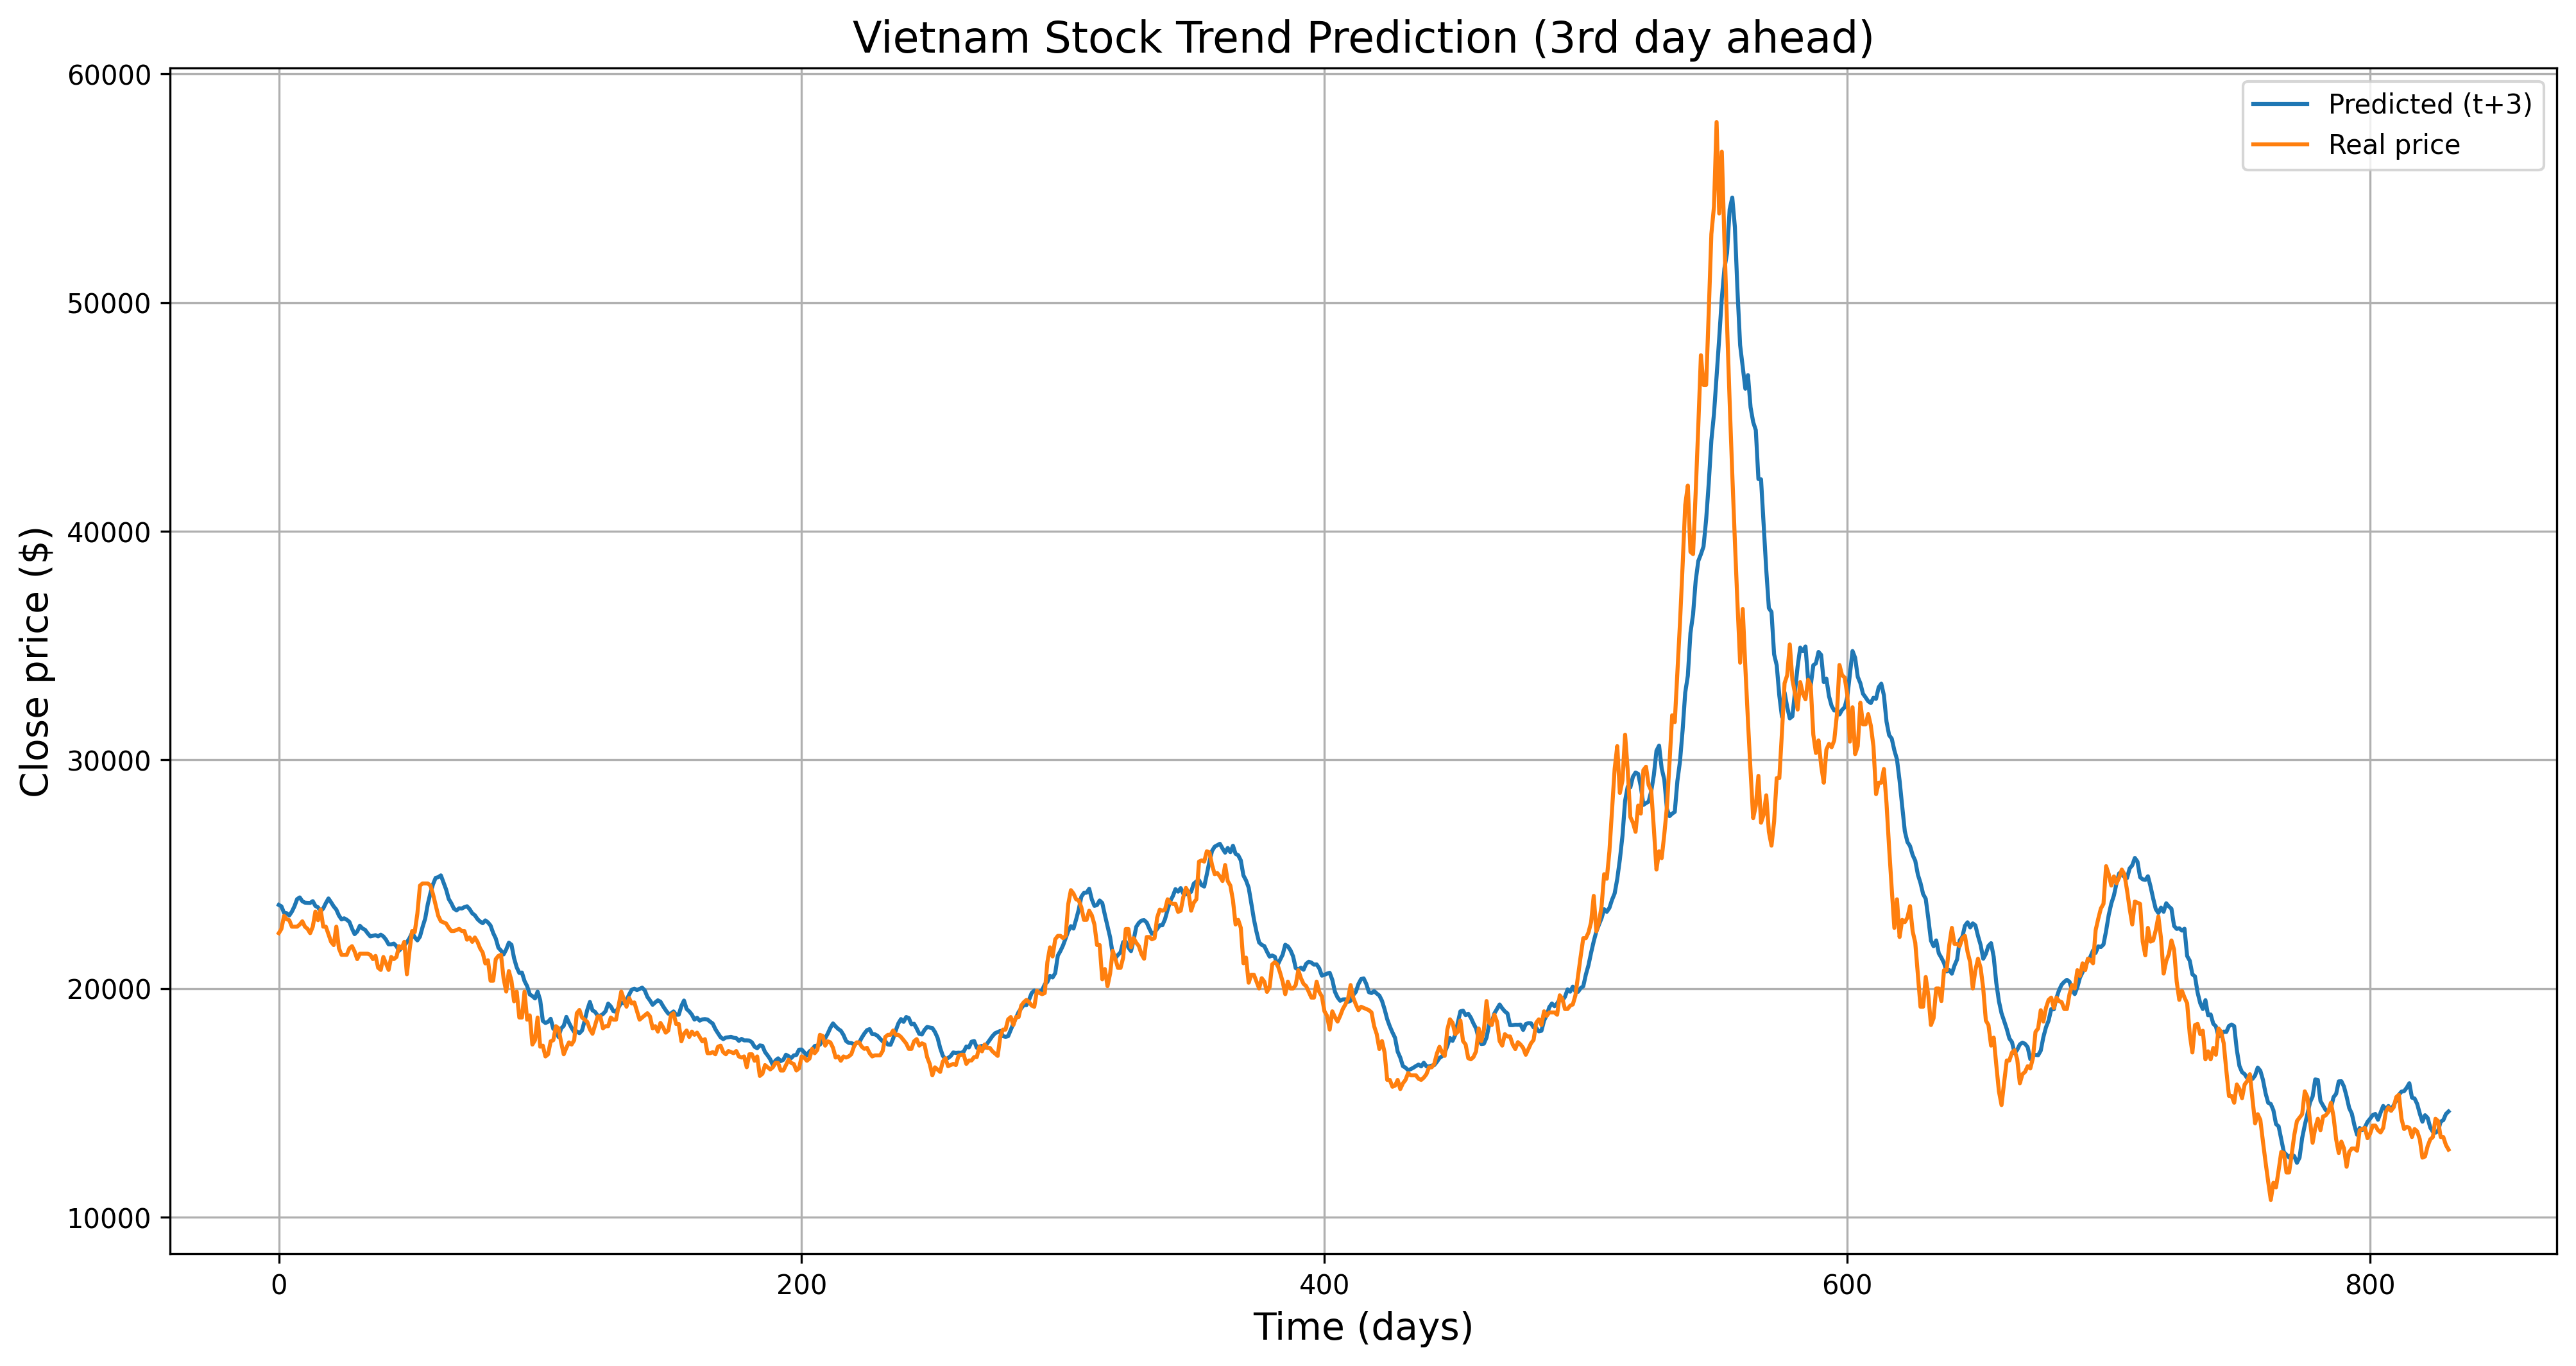

In [16]:
# Visualization
plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred, label=f'Predicted (t+{k})')
plt.plot(y_test, label='Real price')
plt.title('Vietnam Stock Trend Prediction (3rd day ahead)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Close price ($)', fontsize=14)
plt.grid()
plt.legend()
plt.show()